In [4]:
import sys
from pathlib import Path

project_root = Path().resolve().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

from src.db_utils import load_sql

print("Модули импортированы")

Модули импортированы


In [6]:
df = load_sql("SELECT * FROM documents")
print(f"Всего отзывов: {len(df)}")


embeddings = np.load('../data/processed/all_review_embeddings.npy')
print(f"Эмбеддинги загружены: {embeddings.shape}")

Всего отзывов: 131669
Эмбеддинги загружены: (131669, 312)


In [ ]:
embedder = SentenceTransformer('cointegrated/rubert-tiny2')


def semantic_search(query, top_k: int = 5) -> pd.DataFrame:

    query_embedding = embedder.encode([query], convert_to_numpy=True)
    
    similarities = cosine_similarity(query_embedding, embeddings)[0]
    
    top_indices = np.argsort(similarities)[-top_k:][::-1]

    results = []
    for idx in top_indices:
        results.append({
            'text': df.iloc[idx]['text'],
            'category': df.iloc[idx]['category'],
            'similarity': similarities[idx],
            'original_idx': idx
        })
    
    return pd.DataFrame(results)

Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [8]:
similarities = [0.3, 0.8, 0.1, 0.9]
np.argsort(similarities)

top_indices = np.argsort(similarities)[-5:][::-1]

In [9]:
query = "отличный фильм с захватывающим сюжетом"
results = semantic_search(query, top_k=5)

print(f"Запрос: '{query}'\n")
for i, row in results.iterrows():
    print(f"{i+1}. [Сходство: {row['similarity']:.3f}] [{row['category']}]")
    print(f"   {row['text'][:150]}...")
    print()

Запрос: 'отличный фильм с захватывающим сюжетом'

1. [Сходство: 0.816] [pos]
   Замечательный приключенческий фильм с прекрасными панорамными съемками и великолепными актерами....

2. [Сходство: 0.788] [pos]
   Очень хороший, трогательный фильм, с очень грустной концовкой....

3. [Сходство: 0.765] [neu]
   Отличный фильм. Безусловно, не для всех. Смелый сценарий и отличные актеры сделали свое дело!...

4. [Сходство: 0.760] [pos]
   Фильм отличный. Смеялся на протяжении всего фильма. Отличная комедия в духе Американского пирога. Это что-то....

5. [Сходство: 0.756] [neu]
   Фильм хорош только своим непрерывным драйвом. Без сюжета, без игры, без режиссуры, без изюминки. Просто сумашедший экшн.
На один раз....



In [10]:
query = "фильм — настоящий шедевр кинематографа"
results = semantic_search(query, top_k=5)

print(f"Запрос: '{query}'\n")
print("Найденные отзывы (обрати внимание — слова могут отличаться!):\n")
for i, row in results.iterrows():
    print(f"{i+1}. [Сходство: {row['similarity']:.3f}] [{row['category']}]")
    print(f"   {row['text'][:150]}...")
    print()

Запрос: 'фильм — настоящий шедевр кинематографа'

Найденные отзывы (обрати внимание — слова могут отличаться!):

1. [Сходство: 0.767] [neu]
   Наше советское кино Хрущёвской оттепели - действительно шедеврально. Этот фильм трогает за душу как ни одна современная мелодрама....

2. [Сходство: 0.743] [neu]
   Очень хороший, качественный фильм. Вообще фильм приятен для просмотра. Это конечно не шедевр мирового кино, но твердую восьмерку я поставлю......

3. [Сходство: 0.741] [pos]
   Фильм отличный. Смеялся на протяжении всего фильма. Отличная комедия в духе Американского пирога. Это что-то....

4. [Сходство: 0.733] [pos]
   Потрясающие съемки. Превосходная операторская работа. Классика документального кинематографа. Фильм стоит в одном ряду с 'Птицами', 'Баракой' и др....

5. [Сходство: 0.730] [neu]
   Прекрасный фильм... Брюс в лучшей своей форме! Харизма, ирония... Сейчас действительно не хватает таких фильмов!...



In [11]:
queries = [
    "мне очень понравилось это кино",
    "фильм был прекрасен",
    "рекомендую к просмотру",
    "отличная работа режиссёра"
]

print("Разные формулировки одного смысла:\n")
for query in queries:
    results = semantic_search(query, top_k=3)
    avg_similarity = results['similarity'].mean()
    print(f"Запрос: '{query}'")
    print(f"Среднее сходство: {avg_similarity:.3f}")
    print(f"Топ-1: [{results.iloc[0]['category']}] {results.iloc[0]['text'][:80]}...")
    print()

Разные формулировки одного смысла:

Запрос: 'мне очень понравилось это кино'
Среднее сходство: 0.756
Топ-1: [neu] Просто в восторге от картины. Давно меня так не радовал отечественный кинематогр...

Запрос: 'фильм был прекрасен'
Среднее сходство: 0.720
Топ-1: [pos] Фильм отличный. Смеялся на протяжении всего фильма. Отличная комедия в духе Амер...

Запрос: 'рекомендую к просмотру'
Среднее сходство: 0.583
Топ-1: [pos] Не могу сдержать улыбки при просмотре. Хочется смотреть ещё и ещё... Но на роль ...

Запрос: 'отличная работа режиссёра'
Среднее сходство: 0.700
Топ-1: [neu] Отличный фильм. Безусловно, не для всех. Смелый сценарий и отличные актеры сдела...



In [12]:
pos_query = "превосходный фильм, всем советую"
neg_query = "ужасный фильм, зря потратил время"

pos_results = semantic_search(pos_query, top_k=3)
neg_results = semantic_search(neg_query, top_k=3)

print("Позитивный запрос:")
print(f"   '{pos_query}'")
for _, row in pos_results.iterrows():
    print(f"   [{row['category']}] {row['text'][:80]}...")

print("\nНегативный запрос:")
print(f"   '{neg_query}'")
for _, row in neg_results.iterrows():
    print(f"   [{row['category']}] {row['text'][:80]}...")

Позитивный запрос:
   'превосходный фильм, всем советую'
   [pos] Отличнейший фильм. Если посмотрите, ни за что не пожалеете. Все на высшем уровне...
   [pos] Один из самых лучших мистических триллеров! Очень впечатляет концовка фильма, а ...
   [neu] Фильм великолепный! Рад за российских кинематографистов. Ставлю фильм в один ряд...

Негативный запрос:
   'ужасный фильм, зря потратил время'
   [neg] Очередной штамп американских фильмов ужасов. Хотелось выключить после 20 минут п...
   [pos] Несмотря на то, что фильм старый, смотреть его интересно и сейчас. К тому же, дл...
   [neg] Да, деньги выброшенны на ветер! Как ни печально, но почти все, что ставится по и...


In [13]:
query = "фильм неплохой, но концовка разочаровала"
results = semantic_search(query, top_k=5)

print(f"Запрос: '{query}'\n")
print("Найденные отзывы:\n")
for i, row in results.iterrows():
    print(f"{i+1}. [Сходство: {row['similarity']:.3f}] [{row['category']}]")
    print(f"   {row['text'][:150]}...")
    print()

Запрос: 'фильм неплохой, но концовка разочаровала'

Найденные отзывы:

1. [Сходство: 0.789] [neu]
   Казалось бы, банальный сюжет для кино, но снят очень 'сильно'! Жаль мало, кто знает этот фильм. Посмотреть его однозначно стоит!...

2. [Сходство: 0.787] [pos]
   Фильм и правда красивый. Сюжет конечно сильно заштампованый, но для такого красивого спинномозговика вполне. С удовольствием посмотрел......

3. [Сходство: 0.781] [neu]
   Фильм понравился тем, как он снят. Хотя сюжета не уловила, но досмотреть до конца все равно хотелось. Была надежда все-таки понять смысл. Но ведь карт...

4. [Сходство: 0.780] [neu]
   Без сомнения фильм хороший. Отдаёт старинкой и временами наивный, но у экрана держит крепко....

5. [Сходство: 0.779] [neu]
   Фильм очень понравился, хотя чуть затянут, но это ничего страшного. Неплохая подборка актеров, сюжет вообше супер! Один из моих любимых фильмов!...



In [ ]:
vectorizer_tfidf = joblib.load('../models/tfidf_vectorizer_v1.pkl')

print("Векторизуем отзывы через TF-IDF...")
tfidf_matrix = vectorizer_tfidf.transform(df['text'])
print(f"Готово! Размер: {tfidf_matrix.shape}")


def tfidf_search(query, top_k: int = 5) -> pd.DataFrame:
    query_tfidf = vectorizer_tfidf.transform([query])
    
    similarities = cosine_similarity(query_tfidf, tfidf_matrix)[0]
    
    top_indices = np.argsort(similarities)[-top_k:][::-1]

    results = []
    for idx in top_indices:
        results.append({
            'text': df.iloc[idx]['text'],
            'category': df.iloc[idx]['category'],
            'similarity': similarities[idx],
            'original_idx': idx
        })
    
    return pd.DataFrame(results)

Векторизуем отзывы через TF-IDF...
Готово! Размер: (131669, 10000)


In [ ]:
query = "кино было великолепным, актёры сыграли превосходно"

print(f"Запрос: '{query}'\n")
print("="*70)

print("\nСЕМАНТИЧЕСКИЙ ПОИСК (эмбеддинги):")
print("-"*70)
sem_results = semantic_search(query, top_k=5)
for i, row in sem_results.iterrows():
    print(f"{i+1}. [Сходство: {row['similarity']:.3f}] [{row['category']}]")
    print(f"   {row['text'][:120]}...")
    print()

print("="*70)

print("\nKEYWORD ПОИСК (TF-IDF):")
print("-"*70)
tfidf_results = tfidf_search(query, top_k=5)
for i, row in tfidf_results.iterrows():
    print(f"{i+1}. [Сходство: {row['similarity']:.3f}] [{row['category']}]")
    print(f"   {row['text'][:120]}...")
    print()

Запрос: 'кино было великолепным, актёры сыграли превосходно'


СЕМАНТИЧЕСКИЙ ПОИСК (эмбеддинги):
----------------------------------------------------------------------
1. [Сходство: 0.816] [neu]
   Отличный фильм. Безусловно, не для всех. Смелый сценарий и отличные актеры сделали свое дело!...

2. [Сходство: 0.799] [pos]
   Замечательный приключенческий фильм с прекрасными панорамными съемками и великолепными актерами....

3. [Сходство: 0.796] [pos]
   Мне лично фильм очень понравился, великолепно подобраны все актеры, играют отлично, спецэффекты красивые, масштабные, и ...

4. [Сходство: 0.770] [pos]
   Очень хороший, милый, свежий и небанальный фильм. Авторам удалось избежать серьёзного использования штампов, вместо этог...

5. [Сходство: 0.770] [pos]
   Милая, нежная, наивная, чувственная драма с впечатляющими пейзажами, приятной музыкой и прекрасной игрой актеров. Фильм ...


KEYWORD ПОИСК (TF-IDF):
----------------------------------------------------------------------
1. [Сходство

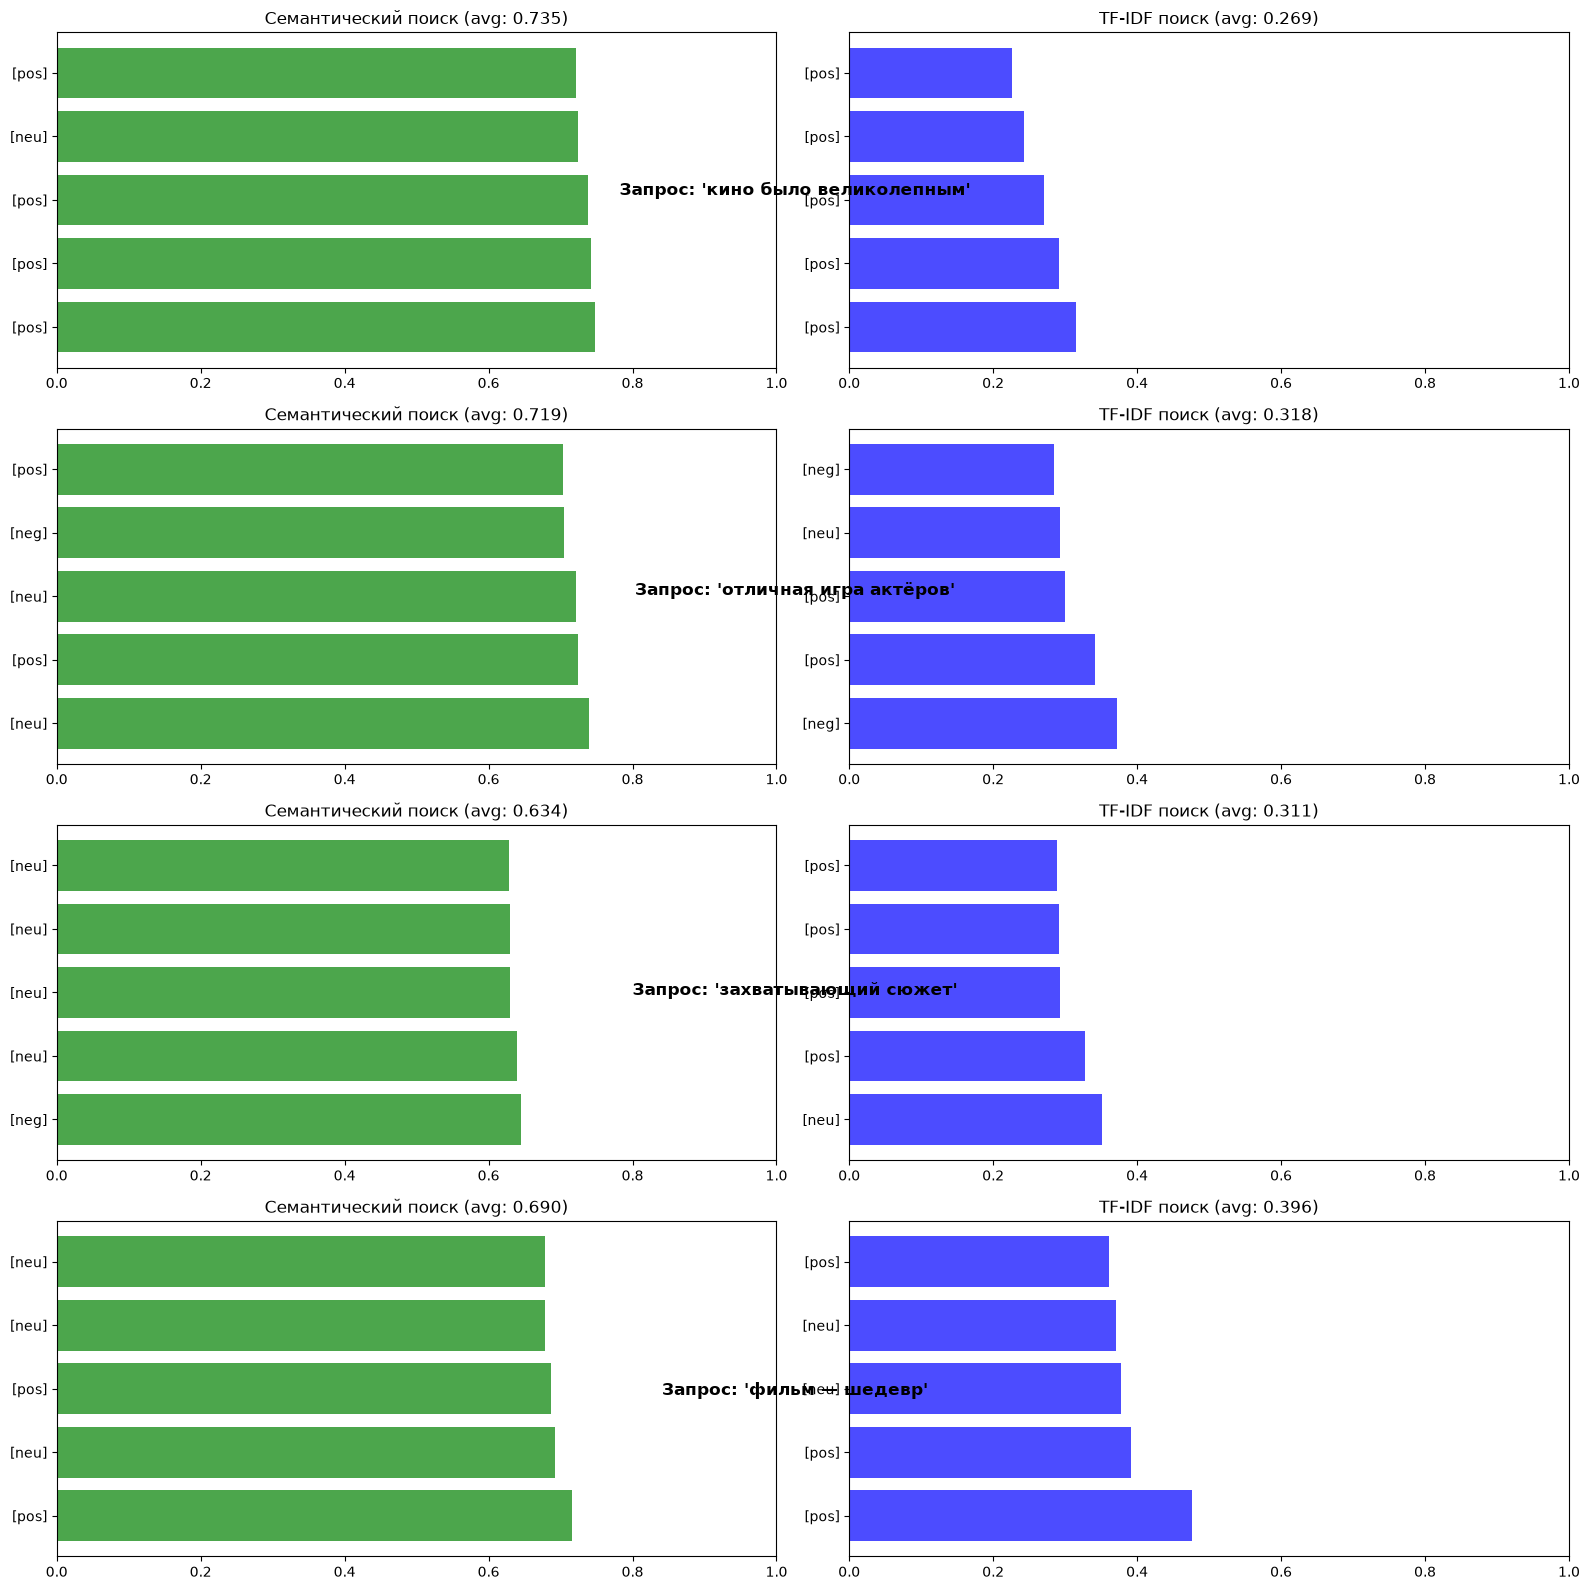

In [20]:
test_queries = [
    "кино было великолепным",
    "отличная игра актёров",
    "захватывающий сюжет",
    "фильм — шедевр"
]

fig, axes = plt.subplots(len(test_queries), 2, figsize=(16, 4*len(test_queries)))

for idx, query in enumerate(test_queries):
    sem_results = semantic_search(query, top_k=5)
    sem_avg = sem_results['similarity'].mean()
    
    tfidf_results = tfidf_search(query, top_k=5)
    tfidf_avg = tfidf_results['similarity'].mean()
    
    axes[idx, 0].barh(
        range(len(sem_results)),
        sem_results['similarity'].values,
        color='green', alpha=0.7
    )
    axes[idx, 0].set_title(f'Семантический поиск (avg: {sem_avg:.3f})')
    axes[idx, 0].set_xlim(0, 1)
    axes[idx, 0].set_yticks(range(len(sem_results)))
    axes[idx, 0].set_yticklabels([f"[{c}]" for c in sem_results['category']])
    
    axes[idx, 1].barh(
        range(len(tfidf_results)),
        tfidf_results['similarity'].values,
        color='blue', alpha=0.7
    )
    axes[idx, 1].set_title(f'TF-IDF поиск (avg: {tfidf_avg:.3f})')
    axes[idx, 1].set_xlim(0, 1)
    axes[idx, 1].set_yticks(range(len(tfidf_results)))
    axes[idx, 1].set_yticklabels([f"[{c}]" for c in tfidf_results['category']])
    
    fig.text(0.5, 1 - (idx+0.5)/len(test_queries), 
             f"Запрос: '{query}'", 
             ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('../data/processed/semantic_vs_tfidf_search.png', dpi=150, bbox_inches='tight')
plt.show()

In [25]:
import pickle

search_index = {
    'embeddings': embeddings,
    'texts': df['text'].tolist(),
    'categories': df['category'].tolist(),
    'model_name': 'cointegrated/rubert-tiny2'
}

with open('../models/search_index.pkl', 'wb') as f:
    pickle.dump(search_index, f)

print(f"Индекс сохранён: models/search_index.pkl")
print(f"Размер: {embeddings.shape}")
print(f"Размер файла: {Path('../models/search_index.pkl').stat().st_size / 1024 / 1024:.1f} МБ")

Индекс сохранён: models/search_index.pkl
Размер: (131669, 312)
Размер файла: 672.6 МБ


In [26]:
def load_search_index(index_path: str = '../models/search_index.pkl'):
    with open(index_path, 'rb') as f:
        return pickle.load(f)


def semantic_search_fast(query, index, top_k: int = 5) -> pd.DataFrame:
    embedder = SentenceTransformer(index['model_name'])
    query_embedding = embedder.encode([query], convert_to_numpy=True)

    similarities = cosine_similarity(query_embedding, index['embeddings'])[0]
    
    top_indices = np.argsort(similarities)[-top_k:][::-1]
    
    results = []
    for idx in top_indices:
        results.append({
            'text': index['texts'][idx],
            'category': index['categories'][idx],
            'similarity': similarities[idx]
        })
    
    return pd.DataFrame(results)

print("Тестируем быстрый поиск...")
index = load_search_index()
results = semantic_search_fast("отличный фильм", index, top_k=3)
print(results[['category', 'similarity', 'text']].head())

Тестируем быстрый поиск...


Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  category  similarity                                               text
0      pos    0.749996  Очень хороший, трогательный фильм, с очень гру...
1      pos    0.740836  Фильм отличный. Смеялся на протяжении всего фи...
2      neu    0.724673  Прекрасный фильм... Брюс в лучшей своей форме!...
